In [3]:
!pip install plotly

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 29.6 MB/s eta 0:00:0000:0100:01


In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
import itertools
import os
import plotly.express as px
import time

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [62]:
fn = '../../Subclustering/PVH/SAM_DR_cleaned_PVH_07172026.h5ad'

sam = SAM()
sam.load_data(fn)

In [63]:
sam_test = SAM()
sam_test.load_data('../../Active_SAM_joined/SAM_DR_ncbi_joined_cleaned_07172026.h5ad')

In [64]:
sam_test.adata.obs.columns

Index(['n_genes', 'n_counts', 'key', 'leiden_clusters_neuron', 'eq_subclass',
       'eq_subclass_lc', 'leiden_clusters', 'eq_subclass_nounlabeled',
       'ss_subclass', 'ss_subclass_v4_nounlabeled',
       'ss_subclass_v4_nounlabeled_nn', 'ss_subclass_nounlabeled_nmm_v4_nn',
       'ss_subclass_nounlabeled_nmm_v4_nn_thresh30',
       'ss_subclass_nounlabeled_nmm_cl_v4_nn', 'neurotransmitter_v3'],
      dtype='object')

In [65]:
tester = sam_test.adata[sam_test.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'] == '133 PVH-SO-PVa Otp Glut']

In [66]:
tester.X

<428x25503 sparse matrix of type '<class 'numpy.float32'>'
	with 149055 stored elements in Compressed Sparse Row format>

In [67]:
sam.adata.X

<428x25503 sparse matrix of type '<class 'numpy.float32'>'
	with 149055 stored elements in Compressed Sparse Row format>

In [68]:
def csr_equal(A, B):
    if A.shape != B.shape:
        return False
    return (A != B).nnz == 0

In [69]:
csr_equal(tester.X,sam.adata.X)

True

In [70]:
sam.clustering(param = 2)

In [2]:
sm = load_samap('../../Subclustering/PVH/sm_hypoorgs_PVH_07282026.pkl')

In [71]:
org_two = 'dr'

In [72]:
sm.sams[org_two].clustering(param = 2)

In [73]:
keys = {'mg':'eq_supertype',org_two:'leiden_clusters'}
D,MappingTable = get_mapping_scores(sm,keys)

lim_MappingTable = MappingTable.filter(like='mg_')
lim_MappingTable = lim_MappingTable[lim_MappingTable.index.str.contains(org_two + '_')]

/scratch/miniconda/lib/python3.7/site-packages/samap/analysis.py:1609: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  samap.adata.obs[l] = pd.Categorical(cl)


In [74]:
lim_MappingTable

,mg_Avp,mg_Crh,mg_Nkx2-2,mg_Oxt,mg_Sst,mg_Trh,mg_Ucn3
dr_0,0.199378,0.073636,0.000009,0.004390,0.259615,0.003278,0.000800
dr_1,0.107303,0.000000,0.035338,0.606367,0.001968,0.008665,0.001212
dr_2,0.276517,0.037056,0.013428,0.000033,0.082988,0.033176,0.000742
dr_3,0.240111,0.010625,0.046420,0.064216,0.000890,0.016831,0.001130
dr_4,0.000535,0.040115,0.553872,0.008110,0.003238,0.016197,0.111143
dr_5,0.072942,0.123221,0.007744,0.010521,0.223218,0.011482,0.014045
dr_6,0.321124,0.000365,0.078288,0.075715,0.002026,0.011030,0.001591
dr_7,0.169405,0.120712,0.000007,0.000732,0.363863,0.022426,0.001919
dr_8,0.662818,0.001658,0.037754,0.092650,0.000043,0.006363,0.000000


In [16]:
fin_mapping = {}
for item in lim_MappingTable.index:
    bm = lim_MappingTable.loc[item,:].idxmax()
    if lim_MappingTable.loc[item,bm] > .2:
        fin_mapping[item] = bm
    else:
        fin_mapping[item] = item
        
fin_labels = []
for item in sam.adata.obs['leiden_clusters']:
    fin_labels.append(fin_mapping[org_two + '_' + str(item)][3:])

In [17]:
sam.adata.obs['test'] = fin_labels

In [160]:
mg_genes = ['Avp','Oxt','Nkx2-2','Ucn3','Sst','Crh','Ucn','Trh',]
mo_genes = ['Avp','Oxt','Nkx2-2','UCN3','Sst','Crh','UCN','Trh',]
cj_genes = ['ENSCJPG00005007573','ENSCJPG00005007570','ENSCJPG00005006711','SST','CRH','UCN','TRH']
ac_genes = ['LOC134299523','LOC134299526','nkx2-2','ucn3','sst','crh','trh']
xt_genes = ['avp','oxt','nkx2-2','ucn3','sst.1','ENSXETG00000035344','UCN','trh']
dr_genes = ['avp','oxt','nkx2.2a','ucn3l','sst1.1','crhb','uts1','trh']

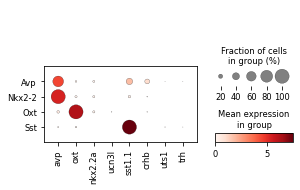

In [162]:
sc.pl.dotplot(sam.adata, groupby = 'test', var_names =dr_genes)

In [124]:
fin_mapping

{'xt_0': 'mg_Sst',
 'xt_1': 'mg_Nkx2-2',
 'xt_10': 'mg_Nkx2-2',
 'xt_11': 'mg_Trh',
 'xt_2': 'xt_2',
 'xt_3': 'mg_Nkx2-2',
 'xt_4': 'mg_Crh',
 'xt_5': 'mg_Oxt',
 'xt_6': 'mg_Nkx2-2',
 'xt_7': 'mg_Crh',
 'xt_8': 'mg_Avp',
 'xt_9': 'mg_Avp'}

In [18]:
sam.adata.obs['test'] = sam.adata.obs['test'].astype('category')

In [19]:
sam.adata.obs['test'].equals(sam.adata.obs['eq_supertype_v3'])

True

In [177]:
fin_labels = []
for item in sam.adata.obs['leiden_clusters']:
    fin_labels.append(fin_mapping[org_two + '_' + str(item)][3:])

In [178]:
sam.adata.obs['eq_supertype_batchcorr'] = fin_labels
sm.sams[org_two].adata.obs['eq_supertype_batchcorr'] = fin_labels

In [179]:
sm.sams[org_two].adata.obs['clusters_batchcorr'] = sam.adata.obs['leiden_clusters']
sam.adata.obs['clusters_batchcorr'] = sam.adata.obs['leiden_clusters']

In [180]:
sam.adata.obs['eq_supertype_v3']

AAAGGGCAGTAGATCA       Avp
AACCTTTCAAAGACGC       Oxt
AAGCATCAGTGTTGAA    Nkx2-2
AAGTCGTGTCCTCAGG       Avp
ACAGAAAGTATGATCC       Sst
                     ...  
TTCGGTCCAGCTATTG       Avp
TTCGGTCCAGGCATTT       Oxt
TTGGGTACAGTTGGTT    Nkx2-2
TTGTTTGCACCGTGAC       Crh
TTTCAGTGTAAGGAGA       Oxt
Name: eq_supertype_v3, Length: 1309, dtype: category
Categories (6, object): ['Avp', 'Crh', 'Nkx2-2', 'Oxt', 'Sst', 'Trh']

In [181]:
sam.adata.obs['eq_supertype_batchcorr'].unique()

array(['Avp', 'Oxt', 'Nkx2-2', 'Sst', 'Crh', 'Trh'], dtype=object)

In [182]:
sam.save_anndata(fn)

In [172]:
save_samap(sm,'../../Subclustering/PVH/sm_hypoorgs_PVH_07282026.pkl')